# Titanic Dataset — Exploratory Data Analysis

## Introduction

The Titanic dataset contains information about passengers aboard the RMS Titanic.

The main objective of this exploratory data analysis (EDA) is to understand the dataset, identify patterns and relationships between passenger characteristics and survival, detect missing values and outliers, and perform feature engineering to create useful variables for further analysis.

### Objectives

- Understand the structure and characteristics of the dataset
- Identify missing values
- Analyze numerical and categorical features
- Study relationships between passenger features and survival
- Detect potential outliers
- Perform feature engineering
- Summarize important findings from the analysis

## Table of Contents

1. [Dataset Overview](#1.-Dataset-Overview)
2. [Understanding the Features](#2.-Understanding-the-Features)
3. [Univariate Analysis](#3.-Univariate-Analysis)
4. [Bivariate Analysis](#4.-Bivariate-Analysis)
5. [Feature Engineering](#5.-Feature-Engineering)
6. [Key Findings](#6.-Key-Findings)
7. [Next Steps](#7.-Next-Steps)

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

## 1. Dataset Overview

Let's begin by loading the dataset and examining its basic structure.

We will check:

- First few rows
- Number of rows and columns
- Column names
- Data types
- Basic statistical information
- Missing values

In [2]:
titanic = pd.read_csv('Data sets/train.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic.shape

(891, 12)

### Dataset Dimensions

The dataset contains 891 observations and 12 columns.

Each row represents a passenger, while each column contains information about that passenger.

## 2. Understanding the Features


- PassengerId → Unique identifier for each passenger
- Survived → Survival status (0 = No, 1 = Yes) 
= Pclass → Passenger class (1st, 2nd, 3rd) 
- Name → Passenger's name 
- Sex → Passenger's gender 
- Age → Passenger's age 
- SibSp → Number of siblings/spouses aboard 
- Parch → Number of parents/children aboard 
- Ticket → Ticket number 
- Fare → Passenger/ticket fare 
- Cabin → Cabin number 
- Embarked → Port of embarkation 

Understanding these variables will help us interpret the patterns discovered during EDA.

###  Column Tpyes
- **Numerical -** Age, Fare, PassengerId
<br>
- **Categorical -** Survived, Pclass, Sex, SibSp, Parch, Embarked
<br>
- **Mixed -** Name, Ticket, Cabin

## 3. Univariate Analysis

Univariate analysis focuses on analyzing each feature in the dataset independently.

- **Distribution analysis**: The distribution of each feature is examined to identify its shape, central tendency, and dispersion.

- **Identifying potential issues**: Univariate analysis helps in identifying potential problems with the data such as outliers, skewness, and missing values

#### Steps of doing Univariate Analysis on **Numerical columns**

- **Descriptive Statistics** : Compute basic summary statistics for the column, such as mean, median, mode, standard deviation, range, and quartiles. These statistics give a general understanding of the distribution of the data and can help identify skewness or outliers.

- **Visualizations** : Create visualizations to explore the distribution of the data. Some common visualizations for numerical data include histograms, box plots, and density plots. These visualizations provide a visual representation of the distribution of the data and can help identify skewness an outliers.

- **Identifying Outliers** : Identify and examine any outliers in the data. Outliers can be identified using visualizations. It is important to determine whether the outliers are due to measurement errors, data entry errors, or legitimate differences in the data, and to decide whether to include or exclude them from the analysis.

- **Skewness** : Check for skewness in the data and consider transforming the data or using robust statistical methods that are less sensitive to skewness, if necessary.

- **Conclusion** : Summarize the findings of the EDA and make decisions about how to proceed with further analysis.


### 3.1 Numerical Features

#### Age
**Conclusions**
- Age ranges from approximately 0.4 to 80 years.
- Around 20% of the Age values are missing.
- The distribution is broadly concentrated around young and middle-aged passengers.

In [4]:
titanic['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

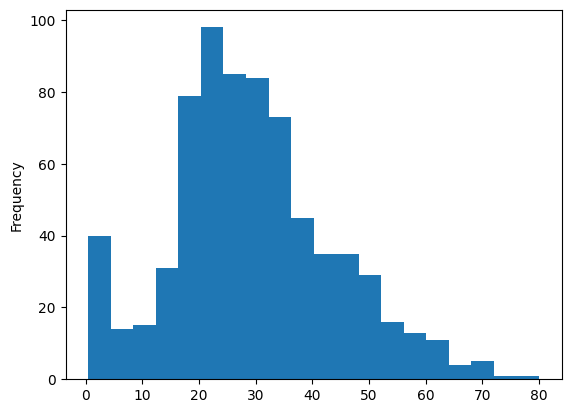

In [5]:
 titanic['Age'].plot(kind='hist', bins=20);

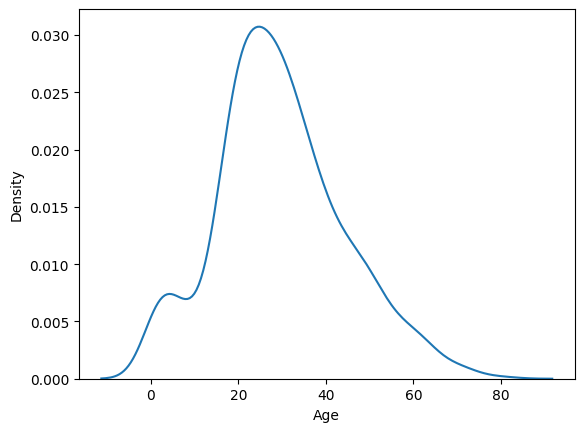

In [6]:
sns.kdeplot(data=titanic, x='Age');

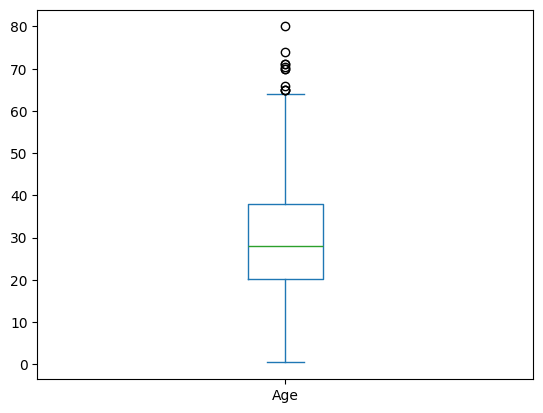

In [7]:
 titanic['Age'].plot(kind='box');

In [8]:
# check for outliers and print them
titanic[titanic['Age'] > 65]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [9]:
(titanic['Age'].isnull().sum() / len(titanic['Age']) ) * 100

np.float64(19.865319865319865)

#### Fare
**Conclusions**
- Data is highly postively skewed.
  
- The `Fare` column represents the fare associated with the ticket. When multiple passengers share the same ticket, this amount may represent the fare for the group rather than the amount attributable to one passenger.

- To obtain an approximate fare per passenger, we divide the ticket fare by the number of passengers associated with the ticket.

In [10]:
titanic['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

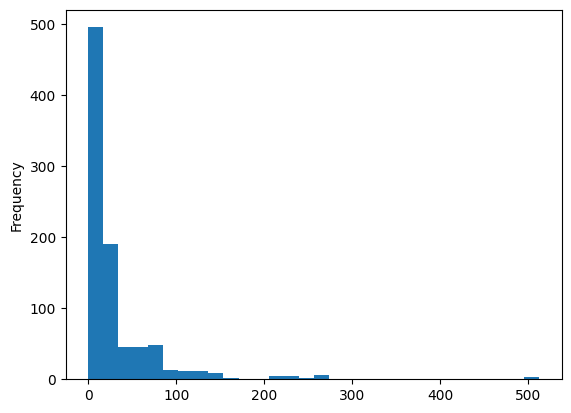

In [11]:
titanic['Fare'].plot(kind='hist', bins=30);

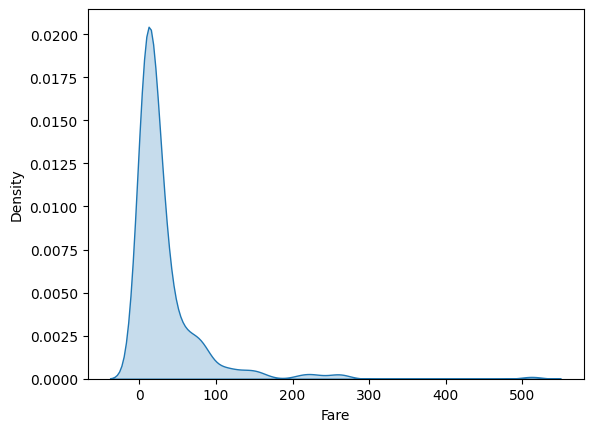

In [12]:
sns.kdeplot(data=titanic, x='Fare', fill=True);

In [13]:
titanic['Fare'].skew()

np.float64(4.787316519674893)

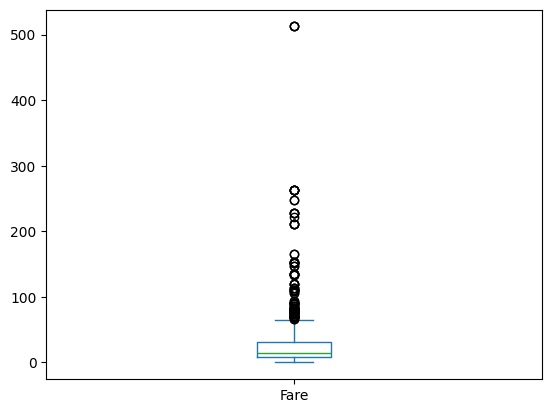

In [14]:
titanic['Fare'].plot(kind='box');

In [15]:
# check the outliers
titanic[titanic['Fare'] > 250]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


In [16]:
titanic['Fare'].isnull().sum()

np.int64(0)

#### Steps of doing Univariate Analysis on **Categorical columns**

**Descriptive Statistics :** Compute the frequency distribution of the categories in the column. This will give a general understanding of the distribution of the categories and their relative frequencies.

**Visualizations :** Create visualizations to explore the distribution of the categories. Some common visualizations for categorical data include count plots and pie charts. These visualizations provide a visual representation of the distribution of the categories and can help identify any patterns or anomalies in the data.

**Missing Values :** Check for missing values in the data and decide how to handle them. Missing values can be imputed or excluded from the analysis, depending on the research question and the data set.

**Conclusion :** Summarize the findings of the EDA and make decisions about how to proceed with further analysis.

### 3.2 Categorical Features

#### Survived 
**Conclusion**
- Approximately 61.6% of passengers in the dataset did not survive, while 38.4% survived.

In [17]:
titanic['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

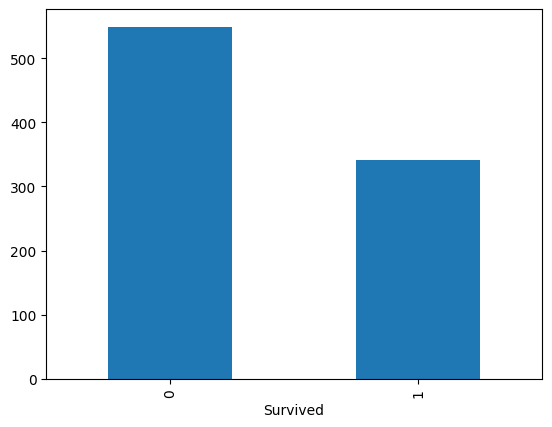

In [18]:
titanic['Survived'].value_counts().plot(kind='bar');

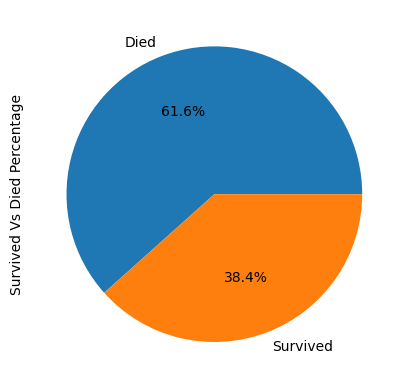

In [19]:
titanic['Survived'].value_counts().plot(kind='pie', autopct='%0.1f%%', labels=['Died', 'Survived'], ylabel = 'Survived Vs Died Percentage');

In [20]:
titanic['Survived'].isnull().sum()

np.int64(0)

#### Pclass 
**Conclusion**
- The number of passangers in Pclass 1 is 216. 
- The number of passangers in Pclass 2 is 184.  
- The number of passangers in Pclass 3 is 491.  

In [21]:
titanic['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

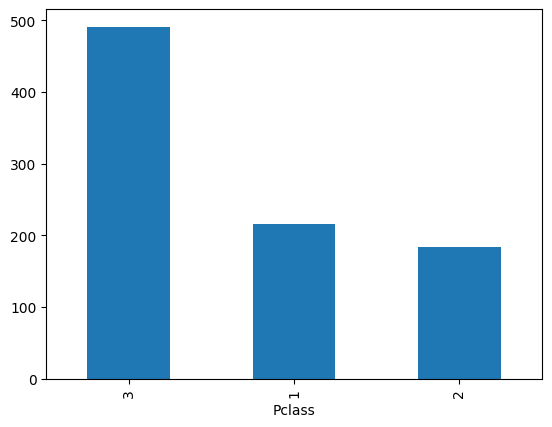

In [22]:
titanic['Pclass'].value_counts().plot(kind='bar');

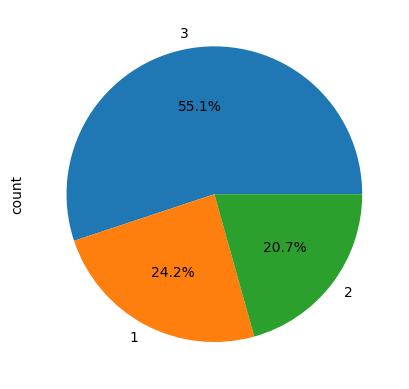

In [23]:
titanic['Pclass'].value_counts().plot(kind='pie', autopct='%0.1f%%');

In [24]:
titanic['Survived'].isnull().sum()

np.int64(0)

#### Sex 
**Conclusion**
- There are 64.8% Males.
- There are 35.2% Females.

In [25]:
titanic['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

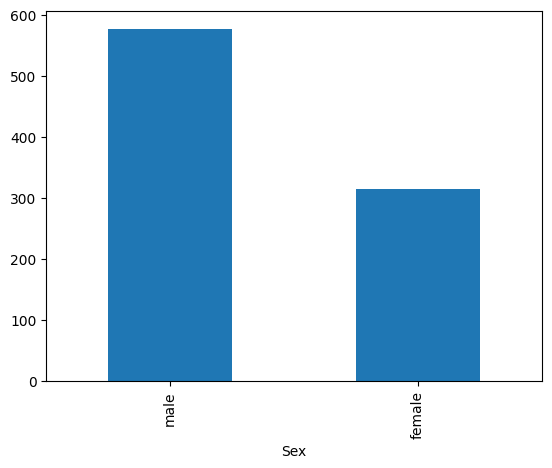

In [26]:
titanic['Sex'].value_counts().plot(kind='bar');

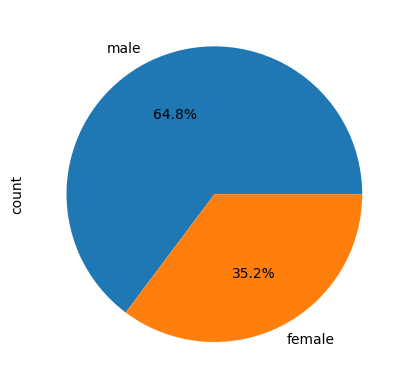

In [27]:
titanic['Sex'].value_counts().plot(kind='pie', autopct='%0.1f%%');

In [28]:
titanic['Sex'].isnull().sum()

np.int64(0)

#### SibSp 
**Conclusion**
- There are 608 peoples are traveling alone. 

In [29]:
titanic['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

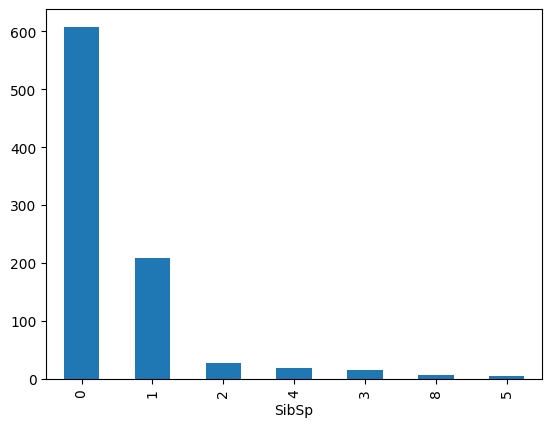

In [30]:
titanic['SibSp'].value_counts().plot(kind='bar');

In [31]:
titanic['SibSp'].isnull().sum()

np.int64(0)

#### Parch
**Conclusion**
- There are 678 travalers are travel without parents.
- Parch  and SibSp cols can be merged to from a new col call family_size.
- Create new col called is_alone.

In [32]:
titanic['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

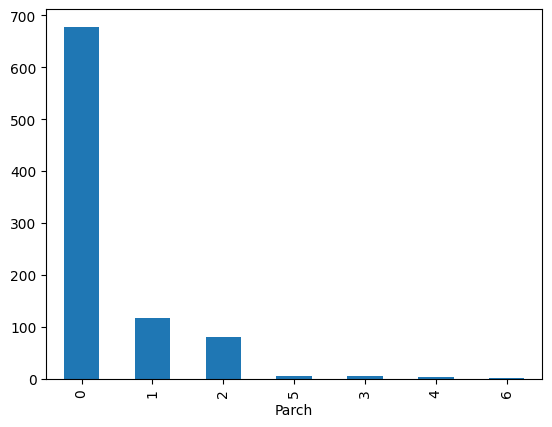

In [33]:
titanic['Parch'].value_counts().plot(kind='bar');

In [34]:
titanic['Parch'].isnull().sum()

np.int64(0)

#### Embarked 
**Conclusion**
- There are 2 missing values.
- There are 72.4% travelers are from the 'S' and 18.9% from 'C' and 8.7% from the 'Q'.

In [35]:
titanic['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

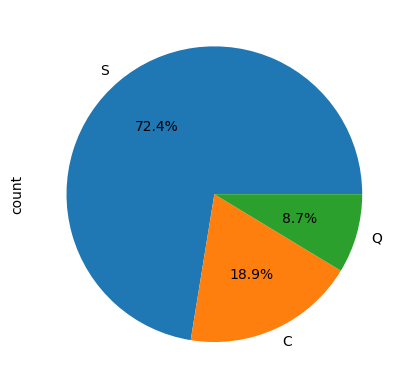

In [36]:
titanic['Embarked'].value_counts().plot(kind='pie', autopct='%0.1f%%');

In [37]:
titanic['Embarked'].isnull().sum()

np.int64(2)

In [38]:
# check the null cols 
titanic[titanic['Embarked'] == None]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


## 4. Bivariate Analysis

Bivariate analysis examines the relationship between two variables.

Since `Survived` is our target variable, we will focus on understanding how different passenger characteristics are associated with survival.

We will investigate relationships between:

- Survival and passenger class
- Survival and sex
- Survival and embarkation port
- Survival and age
- Other engineered features and survival

### Steps in  Bivariate Analysis
- Select Two Cols
- Understand type of releationship

      1. Numerical - Numerical → Plots graph like scatterplot, regression plot, 2D histplot, 2D kdeplot.
      2. Numerical - Categorical → Plots graph like barplot, kdeplot, violinplot, also scatter plot.
      3. Categorical - Categorical → Plots graph like heatmap, stacked barplot, treemaps.

- Conclusions

In [39]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 4.1 Survival vs Passenger Class
**Conclusions**
- In Pclass 1 `63.0%` peoples are survived.
- In Pclass 2 `47.3%` peoples are survived.
- In Pclass 3 `24.2%` peoples are survived.
-  So here we clear see this in the PClass 3 have `highest survived` chance and in the PClass 1 have `lowest survived` chance.

In [40]:
pd.crosstab(titanic['Survived'], titanic['Pclass'])

Pclass,1,2,3
Survived,,,
0,80,97,372
1,136,87,119


In [41]:
round(pd.crosstab(titanic['Survived'], titanic['Pclass'], normalize='columns') * 100, 2)

Pclass,1,2,3
Survived,,,
0,37.04,52.72,75.76
1,62.96,47.28,24.24


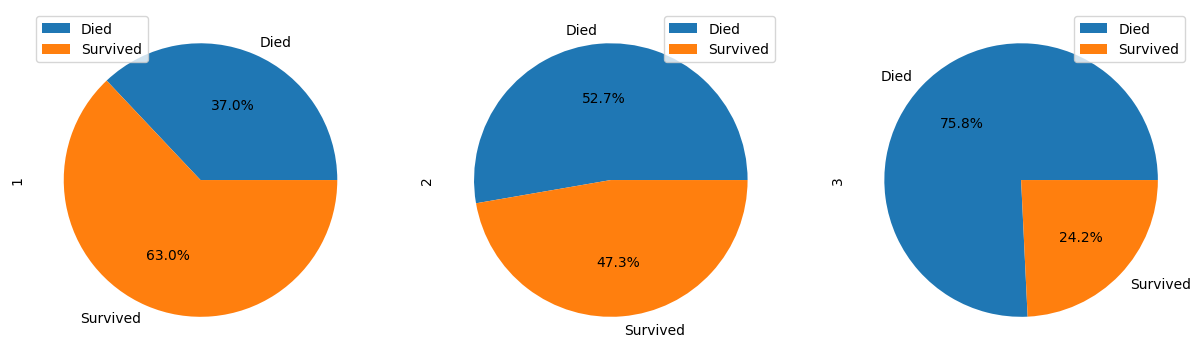

In [42]:
round(pd.crosstab(titanic['Survived'], titanic['Pclass'], normalize='columns') * 100, 2).plot(kind='pie', subplots=True, autopct='%0.1f%%', figsize=(15,7), labels=['Died', 'Survived']);

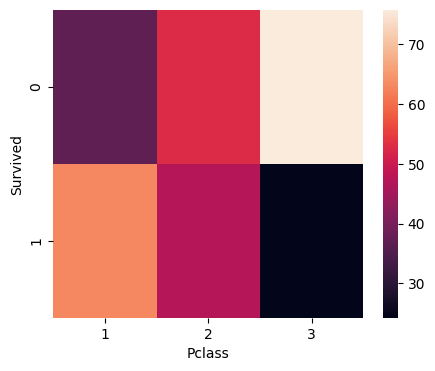

In [43]:
plt.figure(figsize=(5,4))
sns.heatmap(round(pd.crosstab(titanic['Survived'], titanic['Pclass'], normalize='columns') * 100, 2));

### 4.2 Survival vs Sex
**Conclusions**
- There are `74.2%` females are survived and only 25.8% are died.
- There are `18.9%` males are survived and only 81.1% are died.
- This indicates that `Sex` is strongly associated with the survival outcome.

In [44]:
round(pd.crosstab(titanic['Survived'], titanic['Sex'], normalize='columns') * 100, 2)

Sex,female,male
Survived,,
0,25.8,81.11
1,74.2,18.89


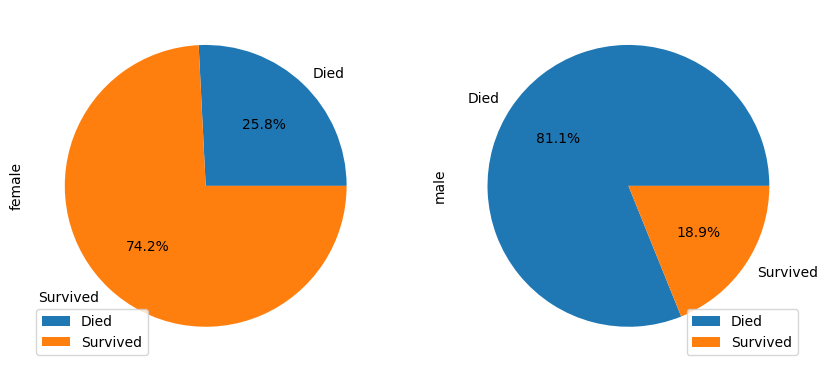

In [45]:
(pd.crosstab(titanic['Survived'], titanic['Sex'], normalize='columns') * 100).plot(kind='pie', subplots=True, figsize=(10,6), autopct='%0.1f%%', labels=['Died', 'Survived']);

### 4.3 Survival vs Embarked 
**Conclusions**
- Passengers embarking at C show a higher survival proportion. This may be related to the passenger-class composition of the group, so we examine Pclass and Embarked together.

In [46]:
round(pd.crosstab(titanic['Survived'], titanic['Embarked'], normalize='columns') * 100, 2)

Embarked,C,Q,S
Survived,,,
0,44.64,61.04,66.3
1,55.36,38.96,33.7


###### Here above we see this that in Embarked C, have survived change is 55.36%, so here may be in Embarked C have most female or may be most passenger travel in Pclass 1.

In [47]:
# check for female
round(pd.crosstab(titanic['Sex'], titanic['Embarked'], normalize='columns') * 100, 2)

Embarked,C,Q,S
Sex,,,
female,43.45,46.75,31.52
male,56.55,53.25,68.48


###### Here we see this there our female assumption is not correct

In [48]:
# check for PClass
round(pd.crosstab(titanic['Pclass'], titanic['Embarked'], normalize='columns') * 100, 2)

Embarked,C,Q,S
Pclass,,,
1,50.60,2.60,19.72
2,10.12,3.90,25.47
3,39.29,93.51,54.81


###### So we clear see in the Embarked C have most passenger that travel in the Pclass 1.

### 4.4 Survival vs Age  
**Conclusions**
- Give to priority save the kids means 0 to 10 age.
- Also their are high chances of survived if age is 30 - 40, because in this range mostly passenge travel in PClass 1.
- Younger passengers show a different survival distribution compared with older passengers. However, age is also related to other variables such as passenger class, so the observed relationship should not be interpreted as a causal effect of age alone.

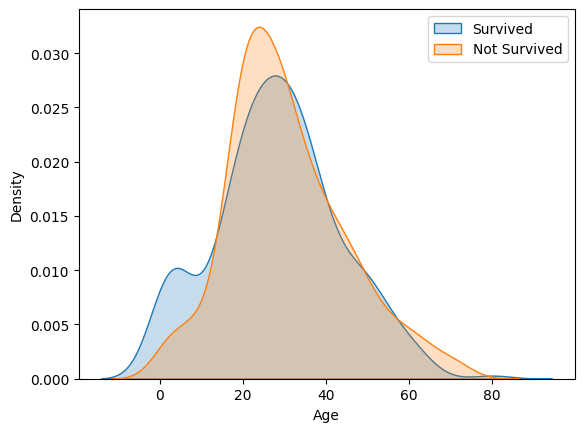

In [49]:
sns.kdeplot(titanic[titanic['Survived'] == 1]['Age'], label='Survived', fill=True)
sns.kdeplot(titanic[titanic['Survived'] == 0]['Age'], label='Not Survived', fill=True)
plt.legend()

In [50]:
print(titanic[titanic['Pclass'] == 1]['Age'].mean())

38.233440860215055


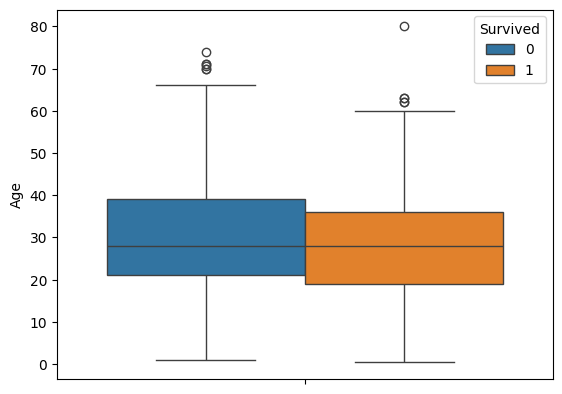

In [51]:
sns.boxplot(data=titanic, y='Age', hue='Survived');

## 5.Feature Engineering 

### 5.1 On the Fare Column

The `Fare` column represents the fare paid for a ticket. However, when multiple passengers share the same ticket, the recorded fare can represent the fare associated with the group rather than a single passenger.

To better understand the fare paid per passenger, we create a new feature called `Individual Fare`.

**Individual Fare = Fare / Number of passengers sharing the ticket**

In [52]:
titanic['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [53]:
titanic[titanic['SibSp'] == 8]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [54]:
titanic[titanic['Ticket'] == 'CA. 2343']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


#### Why combine the training and test datasets?

- The `Ticket` feature can represent multiple passengers traveling under the same ticket. Therefore, to understand shared-ticket patterns and calculate individual fare correctly, we temporarily combine the training and test datasets.

- This combined dataset is used only for exploratory feature construction and understanding ticket-level information.

- The target variable `Survived` remains available only for the training observations.

In [55]:
df = pd.read_csv('Data sets/test.csv')
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [56]:
titanic = pd.concat([titanic, df])
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [57]:
titanic[titanic['Ticket'] == 'CA. 2343']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0.0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0.0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0.0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0.0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0.0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0.0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0.0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S
188,1080,NaN,3,"Sage, Miss. Ada",female,NaN,8,2,CA. 2343,69.55,NaN,S
342,1234,NaN,3,"Sage, Mr. John George",male,NaN,1,9,CA. 2343,69.55,NaN,S
360,1252,NaN,3,"Sage, Master. William Henry",male,14.5,8,2,CA. 2343,69.55,NaN,S


In [58]:
titanic['Fare']/(titanic['SibSp'] + titanic['Parch'] + 1)

0        3.625000
1       35.641650
2        7.925000
3       26.550000
4        8.050000
          ...    
413      8.050000
414    108.900000
415      7.250000
416      8.050000
417      7.452767
Length: 1309, dtype: float64

In [59]:
titanic['Individual Fare'] = titanic['Fare']/(titanic['SibSp'] + titanic['Parch'] + 1)

In [60]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Individual Fare
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000


#### Univariate Analysis on Individual Fare
**Colclusion**
- There are one male and a female their ticket price is 512$, which is suprisely.

In [61]:
titanic['Individual Fare'].describe()

count    1308.000000
mean       20.518215
std        35.774337
min         0.000000
25%         7.452767
50%         8.512483
75%        24.237500
max       512.329200
Name: Individual Fare, dtype: float64

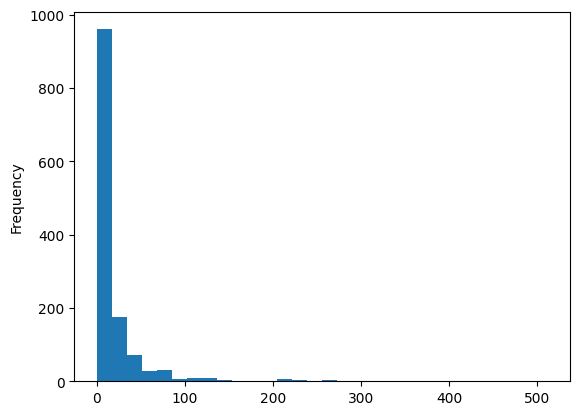

In [62]:
titanic['Individual Fare'].plot(kind='hist', bins=30);

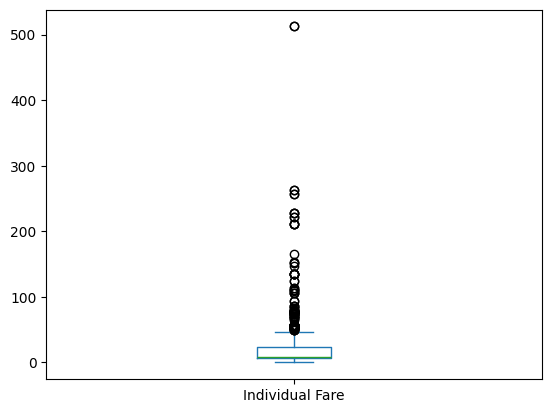

In [63]:
titanic['Individual Fare'].plot(kind='box');

In [64]:
titanic[titanic['Individual Fare'] > 500]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Individual Fare
258,259,1.0,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C,512.3292
737,738,1.0,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,512.3292


#### Bivariate Analysis on Individual Fare
**Colclusion**
- People who paid higher fare the survived chance is more. 

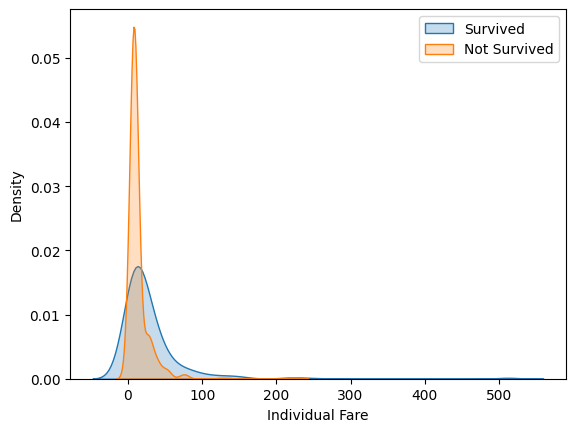

In [65]:
sns.kdeplot(titanic[titanic['Survived'] == 1]['Individual Fare'], label='Survived', fill=True)
sns.kdeplot(titanic[titanic['Survived'] == 0]['Individual Fare'], label='Not Survived', fill=True)
plt.legend()

### 5.2 On the SibSp and Parch column

`SibSp` and `Parch` both provide information about a passenger's family relationships aboard the Titanic.

We combine these variables to create:

**Family Size = SibSp + Parch + 1**

The additional `1` represents the passenger themselves.

In [66]:
# create 'Family_size' col
titanic['Family size'] = titanic['Parch'] + titanic['SibSp'] + 1

In [67]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Individual Fare,Family size
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500,2
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000,1


In [68]:
# create 'Family type' col
# 1 = alone
# 2 to 4 = small
# > 5 = large

def family_size(num): 
    if num == 1: 
        return 'Alone'
    elif num > 1 and num < 5: 
        return 'Small'
    else:
        return 'Large'

In [69]:
titanic['Family size'].apply(family_size)

0      Small
1      Small
2      Alone
3      Small
4      Alone
       ...  
413    Alone
414    Alone
415    Alone
416    Alone
417    Small
Name: Family size, Length: 1309, dtype: object

In [70]:
titanic['Family Type'] = titanic['Family size'].apply(family_size)

In [71]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Individual Fare,Family size,Family Type
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500,2,Small
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2,Small
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1,Alone
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2,Small
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000,1,Alone


#### Univariate Analysis on Family size and Family Type
**Colclusion**
- Most of the peoples are traveling with 1 to 4 memebers.
- There are a family with traveling with 11 members in Pclass 3.
- There are 60.4% peoples are traving Alone.

In [72]:
# Family size
titanic['Family size'].describe()

count    1309.000000
mean        1.883881
std         1.583639
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        11.000000
Name: Family size, dtype: float64

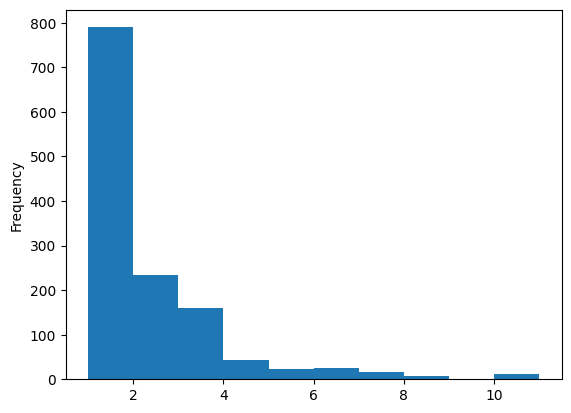

In [73]:
titanic['Family size'].plot(kind='hist');

In [74]:
titanic[titanic['Family size'] == 11]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Individual Fare,Family size,Family Type
159,160,0.0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S,6.322727,11,Large
180,181,0.0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S,6.322727,11,Large
201,202,0.0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S,6.322727,11,Large
324,325,0.0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S,6.322727,11,Large
792,793,0.0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S,6.322727,11,Large
846,847,0.0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S,6.322727,11,Large
863,864,0.0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S,6.322727,11,Large
188,1080,NaN,3,"Sage, Miss. Ada",female,NaN,8,2,CA. 2343,69.55,NaN,S,6.322727,11,Large
342,1234,NaN,3,"Sage, Mr. John George",male,NaN,1,9,CA. 2343,69.55,NaN,S,6.322727,11,Large
360,1252,NaN,3,"Sage, Master. William Henry",male,14.5,8,2,CA. 2343,69.55,NaN,S,6.322727,11,Large


In [75]:
# Family type 
titanic['Family Type'].value_counts()

Family Type
Alone    790
Small    437
Large     82
Name: count, dtype: int64

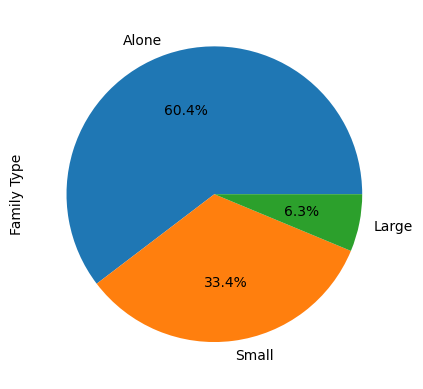

In [76]:
titanic['Family Type'].value_counts().plot(kind='pie', autopct='%0.1f%%', ylabel= 'Family Type');

#### Bivariate Analysis on Family Type
**Colclusion**
- In Small family the % of servived people is 57.9%.
- In Alone family the % of servived people is 30.1%.
- In Large family the % of servived people is 16.1%.

In [77]:
round(pd.crosstab(titanic['Survived'], titanic['Family Type'], normalize='columns') * 100, 2)

Family Type,Alone,Large,Small
Survived,,,
0.0,69.65,83.87,42.12
1.0,30.35,16.13,57.88


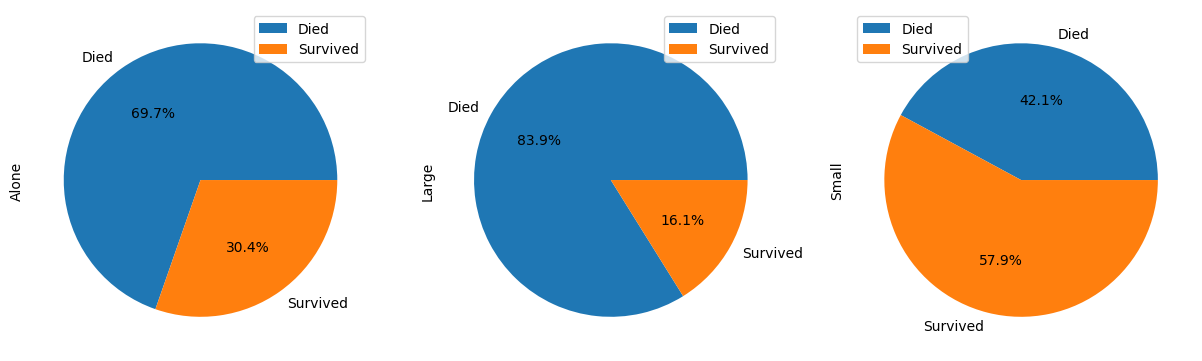

In [78]:
round(pd.crosstab(titanic['Survived'], titanic['Family Type'], normalize='columns') * 100, 2).plot(kind='pie', subplots=True, figsize=(15,6), autopct='%0.1f%%', labels=['Died', 'Survived']);

### 5.3 On the Name column

**Extracting Information from Name**

The `Name` column contains structured information that can be extracted into useful features.

We create:

- `Surname` — family surname
- `Title` — social/professional title extracted from the passenger's name

Rare titles are grouped into `Other` to reduce the number of categories.

In [79]:
# make Surname col
titanic['Surname'] = titanic['Name'].str.split(',').str.get(0)

In [80]:
# create new col title
titanic['tittle'] = titanic['Name'].str.split(',').str.get(1).str.strip().str.split(' ').str.get(0)

In [81]:
titanic['tittle'].value_counts()

tittle
Mr.          757
Miss.        260
Mrs.         197
Master.       61
Rev.           8
Dr.            8
Col.           4
Major.         2
Mlle.          2
Ms.            2
Mme.           1
Don.           1
Sir.           1
Lady.          1
Capt.          1
the            1
Jonkheer.      1
Dona.          1
Name: count, dtype: int64

In [82]:
# replace the unknown title into other
repacement = {
    'Rev.':'Other', 
    'Dr.':'Other',  
    'Col.':'Other',  
    'the':'Other',
    'Major.':'Other', 
    'Capt.':'Other', 
    'Jonkheer.':'Other', 
    'Lady.':'Mrs.', 
    'Mme.':'Mrs.', 
    'Ms.':'Mrs.', 
    'Mlle.':'Mrs.', 
    'Dona.':'Mrs.', 
    'Sir.':'Mr.',
    'Don.':'Other'
}

In [83]:
titanic['tittle'] = titanic['tittle'].replace(repacement)

#### Univariate Analysis on 'tittle' col

In [84]:
titanic['tittle'].value_counts()

tittle
Mr.        758
Miss.      260
Mrs.       204
Master.     61
Other       26
Name: count, dtype: int64

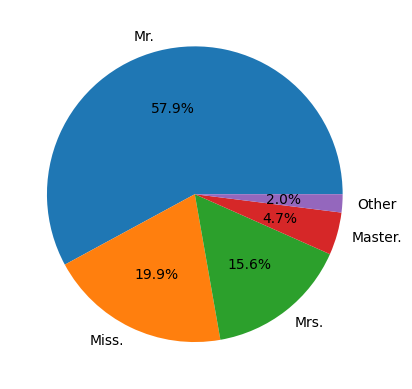

In [85]:
titanic['tittle'].value_counts().plot(kind='pie', autopct='%0.01f%%', ylabel='');

#### Bivariate Analysis on 'tittle' col

In [86]:
temp_df = round(pd.crosstab(titanic['Survived'], titanic['tittle'], normalize='columns') * 100)

In [87]:
temp_df

tittle,Master.,Miss.,Mr.,Mrs.,Other
Survived,,,,,
0.0,42.0,30.0,84.0,20.0,71.0
1.0,57.0,70.0,16.0,80.0,29.0


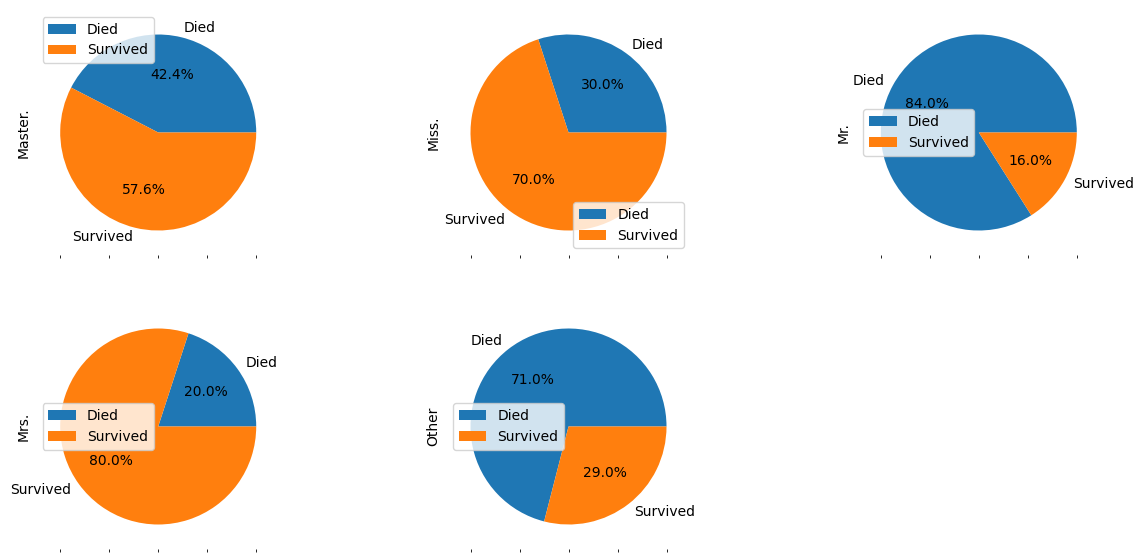

In [88]:
temp_df.plot(kind='pie', subplots=True, figsize=(15,7),layout=(2, 3), autopct='%00.1f%%', labels=['Died', 'Survived']);

In [89]:
temp_df

tittle,Master.,Miss.,Mr.,Mrs.,Other
Survived,,,,,
0.0,42.0,30.0,84.0,20.0,71.0
1.0,57.0,70.0,16.0,80.0,29.0


Text(0.5, 1.0, 'Survived Chance with the tittle')

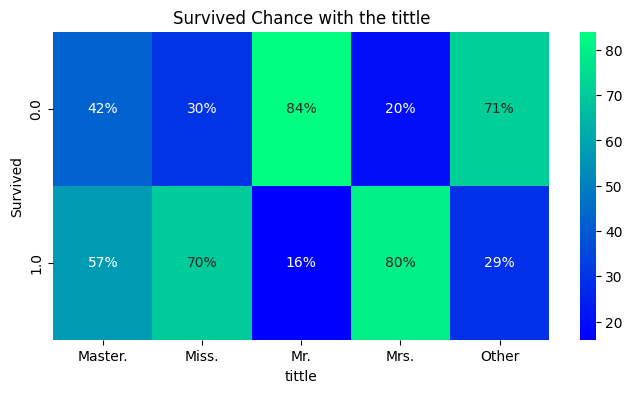

In [90]:
plt.figure(figsize=(8,4))
sns.heatmap(temp_df, annot=True, cmap='winter')

# add % sign
for text in plt.gca().texts:
    text.set_text(text.get_text() + '%')

plt.title('Survived Chance with the tittle')

### 5.4 On the Cabin column 

**Extracting Deck from Cabin**

- The `Cabin` column contains a large number of missing values.
- Instead of using the complete cabin number directly, we extract the first character of the cabin value, which represents the deck.
- For passengers without a recorded cabin, we assign `None`.
- This creates a simpler categorical feature called `Deck`.

In [91]:
print(f'{round(titanic['Cabin'].isnull().sum() / len(titanic['Cabin']) * 100)}%')

77%


In [92]:
titanic[titanic['Cabin'] == 'G6' ]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Individual Fare,Family size,Family Type,Surname,tittle
10,11,1.0,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,5.566667,3,Small,Sandstrom,Miss.
205,206,0.0,3,"Strom, Miss. Telma Matilda",female,2.0,0,1,347054,10.4625,G6,S,5.231250,2,Small,Strom,Miss.
251,252,0.0,3,"Strom, Mrs. Wilhelm (Elna Matilda Persson)",female,29.0,1,1,347054,10.4625,G6,S,3.487500,3,Small,Strom,Mrs.
394,395,1.0,3,"Sandstrom, Mrs. Hjalmar (Agnes Charlotta Bengt...",female,24.0,0,2,PP 9549,16.7000,G6,S,5.566667,3,Small,Sandstrom,Mrs.
117,1009,NaN,3,"Sandstrom, Miss. Beatrice Irene",female,1.0,1,1,PP 9549,16.7000,G6,S,5.566667,3,Small,Sandstrom,Miss.


In [93]:
titanic[titanic['Surname'] == 'Sandstrom']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Individual Fare,Family size,Family Type,Surname,tittle
10,11,1.0,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7,G6,S,5.566667,3,Small,Sandstrom,Miss.
394,395,1.0,3,"Sandstrom, Mrs. Hjalmar (Agnes Charlotta Bengt...",female,24.0,0,2,PP 9549,16.7,G6,S,5.566667,3,Small,Sandstrom,Mrs.
117,1009,NaN,3,"Sandstrom, Miss. Beatrice Irene",female,1.0,1,1,PP 9549,16.7,G6,S,5.566667,3,Small,Sandstrom,Miss.


In [94]:
titanic['Cabin']

0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
413     NaN
414    C105
415     NaN
416     NaN
417     NaN
Name: Cabin, Length: 1309, dtype: object

In [95]:
titanic['Cabin'].value_counts()

Cabin
C23 C25 C27        6
G6                 5
B57 B59 B63 B66    5
F33                4
F4                 4
                  ..
C39                1
B24                1
D40                1
D38                1
C105               1
Name: count, Length: 186, dtype: int64

In [96]:
titanic['Cabin'].fillna('None', inplace=True)

In [97]:
titanic['Cabin'].value_counts()

Cabin
None               1014
C23 C25 C27           6
G6                    5
B57 B59 B63 B66       5
F33                   4
                   ... 
C39                   1
B24                   1
D40                   1
D38                   1
C105                  1
Name: count, Length: 187, dtype: int64

In [98]:
titanic['Deck'] = titanic['Cabin'].str[0]

In [99]:
titanic['Deck'] = titanic['Deck'].str.replace('N', 'None')

In [100]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Individual Fare,Family size,Family Type,Surname,tittle,Deck
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,None,S,3.62500,2,Small,Braund,Mr.,None
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2,Small,Cumings,Mrs.,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,None,S,7.92500,1,Alone,Heikkinen,Miss.,None
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2,Small,Futrelle,Mrs.,C
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,None,S,8.05000,1,Alone,Allen,Mr.,None


#### Univarite Analaysis On Deck col 
**Colclusions** 
- There are 77.5% value are None.

In [101]:
titanic['Deck'].value_counts()

Deck
None    1014
C         94
B         65
D         46
E         41
A         22
F         21
G          5
T          1
Name: count, dtype: int64

<Axes: ylabel='count'>

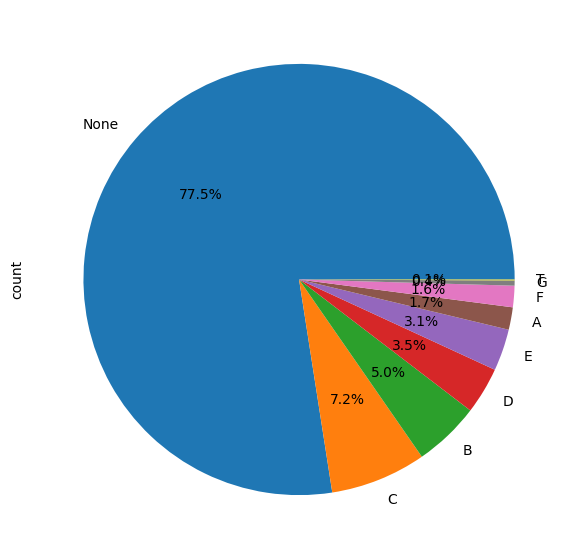

In [102]:
titanic['Deck'].value_counts().plot(kind='pie', autopct='%0.1f%%', figsize=(7,7))

#### Bivarite Analaysis On Deck col 
**Colclusions** 
- There are most servived chance in the Deck B, D, E, F compair to other Deck.
- All Passangers are died that are in Deck T.
- In Deck G 50% passangers are died.

In [103]:
pd.crosstab(titanic['Survived'], titanic['Deck'])

Deck,A,B,C,D,E,F,G,None,T
Survived,,,,,,,,,
0.0,8,12,24,8,8,5,2,481,1
1.0,7,35,35,25,24,8,2,206,0


In [104]:
round(pd.crosstab(titanic['Survived'], titanic['Deck'], normalize='columns') * 100, 2)

Deck,A,B,C,D,E,F,G,None,T
Survived,,,,,,,,,
0.0,53.33,25.53,40.68,24.24,25.0,38.46,50.0,70.01,100.0
1.0,46.67,74.47,59.32,75.76,75.0,61.54,50.0,29.99,0.0


Text(0.5, 1.0, 'Survived Chance In Decks')

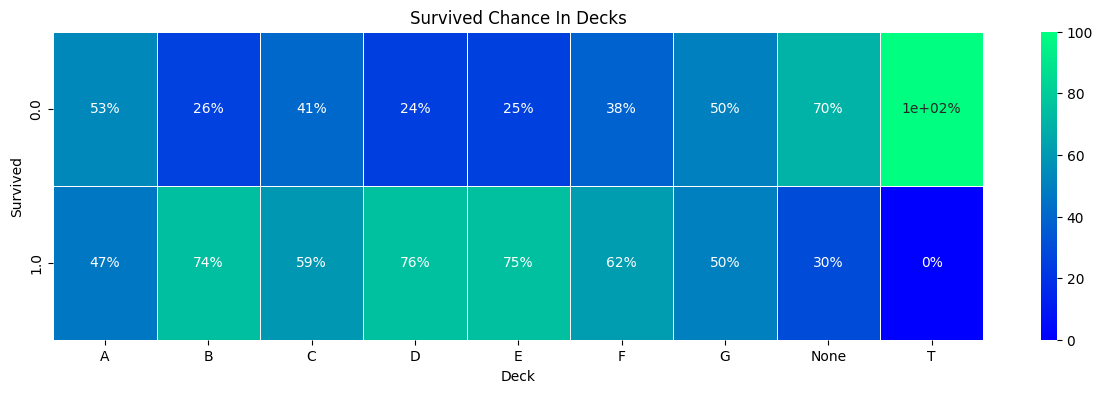

In [105]:
plt.figure(figsize=(15,4))
sns.heatmap(round(pd.crosstab(titanic['Survived'], titanic['Deck'], normalize='columns') * 100, 2),  annot=True, cmap='winter', linewidths=0.5)

# add % sign
for text in plt.gca().texts:
    text.set_text(text.get_text() + '%')
plt.title('Survived Chance In Decks')

In [106]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Individual Fare,Family size,Family Type,Surname,tittle,Deck
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,None,S,3.62500,2,Small,Braund,Mr.,None
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2,Small,Cumings,Mrs.,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,None,S,7.92500,1,Alone,Heikkinen,Miss.,None
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2,Small,Futrelle,Mrs.,C
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,None,S,8.05000,1,Alone,Allen,Mr.,None


## 6. Key Findings

Based on the exploratory analysis, several important patterns were observed:

#### Passenger Class
- Survival proportion differs considerably across passenger classes, with first-class passengers showing a higher survival proportion than passengers in lower classes.

#### Sex
- There is a substantial difference in survival proportions between male and female passengers.

#### Age
- Age distributions differ between survivors and non-survivors, although age is also related to other passenger characteristics.

#### Embarked
- Survival proportions vary by embarkation port. Passenger-class composition provides one possible factor associated with this difference.

#### Family Size
- Passengers belonging to small families show a different survival pattern compared with passengers traveling alone or in large families.

#### Fare
- Fare is strongly skewed, and the analysis suggests that fare-related variables may contain useful information about passenger survival.

#### Title
- Passenger titles reveal additional demographic and social information that may be useful for further analysis.

#### Deck
- Deck information shows differences in survival proportions, although the large number of missing cabin values limits interpretation.

## 7. Next Steps

The EDA provides several features that may be useful for predictive modeling.

Potential next steps include:

- Handling missing values
- Encoding categorical variables
- Selecting relevant features
- Scaling numerical variables where appropriate
- Building classification models
- Evaluating model performance